## Let's run intron clustering to annotate alternative splicing events given observed junctions in our cells 

In [25]:
# Load LeafletSC 
import LeafletSC
import os
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

# Define path that contains junction files
juncs_path = "/gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Leaflet/junctions/RH_astrocytes/"
print("The junctions are loaded from the following path: " + juncs_path) 

# print the files in the path 
print("The files in the path are: " + str(os.listdir(juncs_path)))

# define path for saving the output data 
output_path = "/commons/projects/knowles_singlecell_splicing/EasySci/Pseudobulks/Leaflet/"

# we provide a gtf file for the human genome as well to make better sense of the junctions that are detected in cells
# please replace with the path to the gtf file on your system
gtf_file="/commons/projects/knowles_singlecell_splicing/EasySci/genome_files/gencode.vM27.annotation.gtf" 

The junctions are loaded from the following path: /gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Leaflet/junctions/RH_astrocytes/
The files in the path are: ['Astrocytes_21mo_male.barcodes', 'Astrocytes_21mo_female.juncs', 'Astrocytes_APOE4_female.juncswbarcodes', 'Astrocytes_3mo_male.barcodes', 'Astrocytes_3mo_male.juncs', 'Astrocytes_21mo_female.juncswbarcodes', 'Astrocytes_21mo_male.juncswbarcodes', 'Astrocytes_5xFAD_male.juncswbarcodes', 'Astrocytes_5xFAD_male.juncs', 'Astrocytes_21mo_male.juncs', 'Astrocytes_21mo_female.barcodes', 'Astrocytes_6mo_female.juncs', 'Astrocytes_APOE4_male.juncs', 'Astrocytes_6mo_male.juncswbarcodes', 'Astrocytes_APOE4_male.barcodes', 'Astrocytes_3mo_female.juncs', 'Astrocytes_5xFAD_male.barcodes', 'Astrocytes_3mo_female.juncswbarcodes', 'Astrocytes_6mo_female.barcodes', 'Astrocytes_6mo_female.juncswbarcodes', 'Astrocytes_3mo_female.barcodes', 'Astrocytes_5xFAD_female.juncs', 'Astrocytes_5xFAD_female.juncswbarcodes', 'Astrocytes_6mo_male.bar

### Let's first define some parameters for the analysis

In [8]:
from LeafletSC.clustering.find_intron_clusters import main as find_intron_clusters
from LeafletSC.clustering.prepare_model_input import main as prep_model_input
from LeafletSC.clustering.find_intron_clusters import visualize_local_events

# define additional parameters 
sequencing_type = "single_cell"

# ensure output files are to be saved in output_path 
output_file = output_path + "Astrocytes_RH_intron_clusters"
junc_bed_file= output_path + "Astrocytes_RH_juncs.bed" # you can load this file into IGV to visualize the junction coordinates 
min_intron_length = 50
max_intron_length = 500000
threshold_inc = 0.01 
min_junc_reads = 2
min_num_cells_wjunc = 1
keep_singletons = False # ignore junctions that do not share splice sites with any other junction (likely const)
junc_suffix = "*.juncswbarcodes" # depends on how you ran regtools 

### Run intron clustering 

In [9]:
# get junc files --> all the files in juncs_path that end in junc_suffix
junc_suff=".juncswbarcodes"
junc_files = [f for f in os.listdir(juncs_path) if f.endswith(junc_suff)]
print("The junc files are: " + str(junc_files))
# make srue junc_files are followed by juncs_path to indicate proper path
junc_files = [juncs_path + f for f in junc_files]

The junc files are: ['Astrocytes_APOE4_female.juncswbarcodes', 'Astrocytes_21mo_female.juncswbarcodes', 'Astrocytes_21mo_male.juncswbarcodes', 'Astrocytes_5xFAD_male.juncswbarcodes', 'Astrocytes_6mo_male.juncswbarcodes', 'Astrocytes_3mo_female.juncswbarcodes', 'Astrocytes_6mo_female.juncswbarcodes', 'Astrocytes_5xFAD_female.juncswbarcodes', 'Astrocytes_APOE4_male.juncswbarcodes', 'Astrocytes_3mo_male.juncswbarcodes']


In [10]:
all_juncs_df = find_intron_clusters(junc_files=junc_files, gtf_file=gtf_file, output_file=output_file, 
                       sequencing_type=sequencing_type, junc_bed_file=junc_bed_file, 
                       threshold_inc=threshold_inc, min_intron = min_intron_length,
                       max_intron=max_intron_length, min_junc_reads=min_junc_reads,
                       singleton=keep_singletons,
                       junc_suffix=junc_suffix, min_num_cells_wjunc=min_num_cells_wjunc,filter_shared_ss=True, 
                       run_notebook = True)

Loading files obtained from single_cell sequencing


 40%|████      | 4/10 [00:00<00:00, 32.14it/s]

Reading in junction files from /gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Leaflet/junctions/RH_astrocytes/Astrocytes_APOE4_female.juncswbarcodes
The number of junction files to be processed is 1
Reading in junction files from /gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Leaflet/junctions/RH_astrocytes/Astrocytes_21mo_female.juncswbarcodes
The number of junction files to be processed is 1
Reading in junction files from /gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Leaflet/junctions/RH_astrocytes/Astrocytes_21mo_male.juncswbarcodes
The number of junction files to be processed is 1
Reading in junction files from /gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Leaflet/junctions/RH_astrocytes/Astrocytes_5xFAD_male.juncswbarcodes
The number of junction files to be processed is 1
Reading in junction files from /gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Leaflet/junctions/RH_astrocytes/Astrocytes_6mo_male.juncswbarcodes
The n

100%|██████████| 10/10 [00:00<00:00, 37.94it/s]


Reading in junction files from /gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Leaflet/junctions/RH_astrocytes/Astrocytes_5xFAD_female.juncswbarcodes
The number of junction files to be processed is 1
Reading in junction files from /gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Leaflet/junctions/RH_astrocytes/Astrocytes_APOE4_male.juncswbarcodes
The number of junction files to be processed is 1
Reading in junction files from /gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Leaflet/junctions/RH_astrocytes/Astrocytes_3mo_male.juncswbarcodes
The number of junction files to be processed is 1
The number of junctions after filtering for intron length is 56453
Making gr object from all junctions across all cell types
The number of junctions after filtering by min_junc_reads 13985
The gtf file you provided is /commons/projects/knowles_singlecell_splicing/EasySci/genome_files/gencode.vM27.annotation.gtf
Reading the gtf may take a minute...


INFO:root:Extracted GTF attributes: ['gene_id', 'gene_type', 'gene_name', 'level', 'mgi_id', 'havana_gene', 'transcript_id', 'transcript_type', 'transcript_name', 'transcript_support_level', 'tag', 'havana_transcript', 'exon_number', 'exon_id', 'protein_id', 'ccdsid', 'ont']


Reading gtf file took 49.33 seconds
The number of unique exons is 447177
The number of unique transcript ids is 140439
The number of unique gene ids is 55358
+++++++++++++++++++++++++++++++++++++++++++++++++++++++
Done extracting exons from gtf file
Annotating junctions with known exons based on input gtf file
The number of junctions after assessing distance to exons is 13933
Clustering intron splicing events by gene_id
The number of clusters after clustering by gene_id is 13836
+--------------+-----------+-----------+--------------+-------+
| Chromosome   | Start     | End       | Strand       | +10   |
| (category)   | (int64)   | (int64)   | (category)   | ...   |
|--------------+-----------+-----------+--------------+-------|
| 1            | 10147467  | 10152477  | +            | ...   |
| 1            | 10147467  | 10152477  | +            | ...   |
| 1            | 104862067 | 104868756 | +            | ...   |
| 1            | 104862067 | 104868756 | +            | ...   |
| ..

In [11]:
# load bed file 
juncs_bed = pd.read_csv(junc_bed_file, sep="\t", header=None)
# remove columns 3 and 4 
juncs_bed = juncs_bed.drop(columns=[3, 4])
juncs_bed.columns = ["Chromosome", "Start", "End", "Strand", "junction_id", "Start_b", "End_b", "gene_id", "gene_name", "transcript_id", "exon_id"]

# cmobine with all_juncs_df and prep df for visualization 
dat_vis = all_juncs_df[["chrom", "chromStart", "chromEnd", "strand", "intron_length", "counts_total", "junction_id", "Cluster"]]
dat_vis = dat_vis.drop_duplicates()
# merge dat_vis with juncs_bed using all common columns 
dat_vis = dat_vis.merge(juncs_bed, how="left", on=["junction_id"])

In [12]:
dat_vis

,chrom,chromStart,chromEnd,strand,intron_length,counts_total,junction_id,Cluster,Chromosome,Start,End,Strand,Start_b,End_b,gene_id,gene_name,transcript_id,exon_id
0,10,5375760,5376254,-,494,3,10_5375760_5376254,41,10,5375760,5376254,-,5375667,5375760,ENSMUSG00000096054.4,Syne1,ENSMUST00000215295.2,ENSMUSE00000361477.4
1,10,5375760,5386738,-,10978,7,10_5375760_5386738,41,10,5375760,5386738,-,5375667,5375760,ENSMUSG00000096054.4,Syne1,ENSMUST00000215295.2,ENSMUSE00000361477.4
2,10,60131782,60133316,+,1534,50,10_60131782_60133316,39,10,60131782,60133316,+,60131725,60131782,ENSMUSG00000004207.15,Psap,ENSMUST00000105465.8,ENSMUSE00000100661.4
3,10,60131782,60134876,+,3094,11,10_60131782_60134876,39,10,60131782,60134876,+,60131725,60131782,ENSMUSG00000004207.15,Psap,ENSMUST00000105465.8,ENSMUSE00000100661.4
4,10,60133325,60134876,+,1551,54,10_60133325_60134876,39,10,60133325,60134876,+,60133316,60133325,ENSMUSG00000004207.15,Psap,ENSMUST00000179238.8,ENSMUSE00001468827.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154,9,75568672,75570474,-,1802,6,9_75568672_75570474,35,9,75568672,75570474,-,75568534,75568672,ENSMUSG00000032181.8,Scg3,ENSMUST00000034699.8,ENSMUSE00000274705.4
155,9,75568672,75570489,-,1817,11,9_75568672_75570489,35,9,75568672,75570489,-,75568534,75568672,ENSMUSG00000032181.8,Scg3,ENSMUST00000034699.8,ENSMUSE00000274705.4
156,X,165166996,165168386,+,1390,12,X_165166996_165168386,66,X,165166996,165168386,+,165166930,165166996,ENSMUSG00000031342.18,Gpm6b,ENSMUST00000112235.8,ENSMUSE00001210480.2
157,X,165166996,165169947,+,2951,5,X_165166996_165169947,66,X,165166996,165169947,+,165166930,165166996,ENSMUSG00000031342.18,Gpm6b,ENSMUST00000112235.8,ENSMUSE00001210480.2


In [13]:
print(len(dat_vis.gene_id.unique()))

57


In [15]:
# viusalize junction 11_68822665_68829914

    chrom  chromStart_kb  chromEnd_kb strand  intron_length  counts_total  \
155     9      75568.672    75570.489      -           1817            11   
154     9      75568.672    75570.474      -           1802             6   

       Start_b      End_b               exon_id  
155  75568.534  75568.672  ENSMUSE00000274705.4  
154  75568.534  75568.672  ENSMUSE00000274705.4  
The junction of interest is 9_75568672_75570474


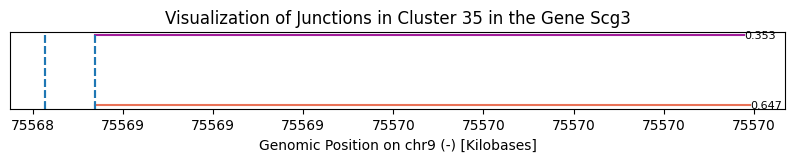

In [14]:
#from LeafletSC.clustering.find_intron_clusters import visualize_junctions
junc_id = all_juncs_df.junction_id.sample(1).values[0]
j = junc_id
visualize_local_events(dat_vis, j, p_usage_ratio=True)

In [16]:
# extract all the unique gene names in all_juncs_df
gene_names = dat_vis.gene_name.unique()
print(len(gene_names))

57


Text(0.5, 1.0, 'Histogram of total reads in junctions')

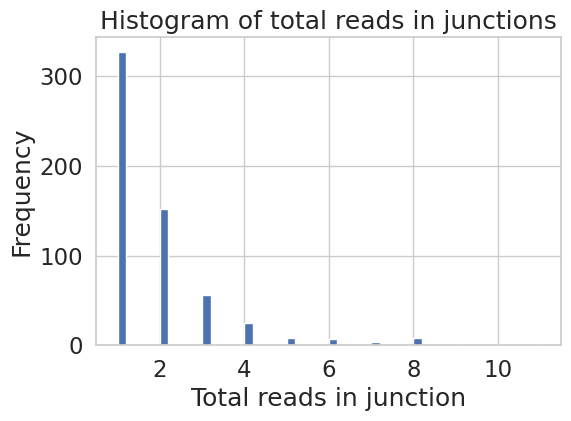

In [17]:
# make plot less wide and icnrease font of everything
plt.figure(figsize=(6, 4))
sns.set(font_scale=1.5)
sns.set_style("whitegrid")
all_juncs_df.score.hist(bins=50)
# add xlab total reads in junction
plt.xlabel("Total reads in junction")
plt.ylabel("Frequency")
plt.title("Histogram of total reads in junctions")

Text(0.5, 1.0, 'Histogram of number of junctions per intron cluster')

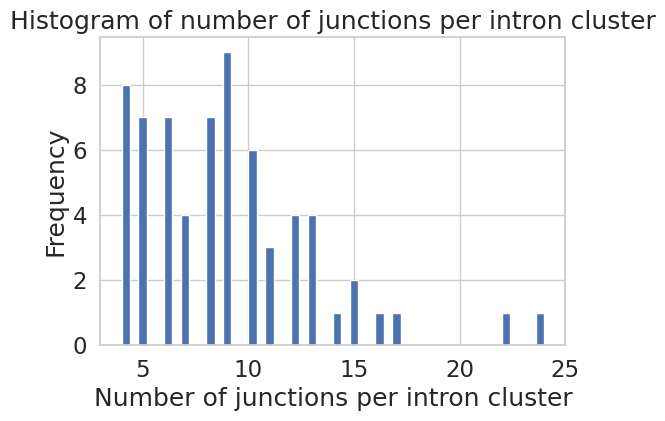

In [18]:
# plot number of junctions per intron cluster 
plt.figure(figsize=(6, 4))
sns.set(font_scale=1.5)
sns.set_style("whitegrid")
all_juncs_df.Cluster.value_counts().hist(bins=50)
# add xlab total reads in junction
plt.xlabel("Number of junctions per intron cluster")
plt.ylabel("Frequency")
plt.title("Histogram of number of junctions per intron cluster")

In [19]:
# find cluster with more than 10 junctions in it
clusters = all_juncs_df.Cluster.value_counts()
clusters = clusters[clusters > 6]
clusters

Cluster
39    24
18    22
17    17
8     16
66    15
59    15
63    14
26    13
62    13
4     13
15    13
45    12
34    12
55    12
1     12
24    11
61    11
53    11
35    10
5     10
38    10
40    10
14    10
64    10
47     9
46     9
29     9
51     9
25     9
44     9
11     9
65     9
13     9
23     8
52     8
16     8
2      8
22     8
32     8
42     8
9      7
27     7
41     7
48     7
Name: count, dtype: int64

In [20]:
all_juncs_df[all_juncs_df["Cluster"] == 39]

,junction_id,counts_total,chrom,chromStart,chromEnd,name,score,strand,thickStart,thickEnd,...,block_add_start,block_subtract_end,intron_length,total_5ss_counts,total_3ss_counts,5SS_usage,3SS_usage,Cluster,gene_id,Count
7,10_60131782_60133316,50,10,60131782,60133316,JUNC00005696,3,+,60131725,60133325,...,57,9,1534,61,50,0.819672,1.000000,39,ENSMUSG00000004207.15,3
8,10_60131782_60133316,50,10,60131782,60133316,JUNC00005544,4,+,60131730,60133325,...,52,9,1534,61,50,0.819672,1.000000,39,ENSMUSG00000004207.15,3
9,10_60131782_60133316,50,10,60131782,60133316,JUNC00008183,8,+,60131725,60133325,...,57,9,1534,61,50,0.819672,1.000000,39,ENSMUSG00000004207.15,3
10,10_60131782_60133316,50,10,60131782,60133316,JUNC00008858,8,+,60131725,60133325,...,57,9,1534,61,50,0.819672,1.000000,39,ENSMUSG00000004207.15,3
11,10_60131782_60133316,50,10,60131782,60133316,JUNC00005212,8,+,60131725,60133325,...,57,9,1534,61,50,0.819672,1.000000,39,ENSMUSG00000004207.15,3
12,10_60131782_60133316,50,10,60131782,60133316,JUNC00013762,10,+,60131725,60133326,...,57,10,1534,61,50,0.819672,1.000000,39,ENSMUSG00000004207.15,3
13,10_60131782_60133316,50,10,60131782,60133316,JUNC00004712,7,+,60131725,60133325,...,57,9,1534,61,50,0.819672,1.000000,39,ENSMUSG00000004207.15,3
14,10_60131782_60133316,50,10,60131782,60133316,JUNC00004155,2,+,60131725,60133325,...,57,9,1534,61,50,0.819672,1.000000,39,ENSMUSG00000004207.15,3
15,10_60131782_60134876,11,10,60131782,60134876,JUNC00005698,2,+,60131727,60134940,...,55,64,3094,61,65,0.180328,0.169231,39,ENSMUSG00000004207.15,3
16,10_60131782_60134876,11,10,60131782,60134876,JUNC00005543,1,+,60131725,60134898,...,57,22,3094,61,65,0.180328,0.169231,39,ENSMUSG00000004207.15,3


  chrom  chromStart_kb  chromEnd_kb strand  intron_length  counts_total  \
2    10      60131.782    60133.316      +           1534            50   
3    10      60131.782    60134.876      +           3094            11   
4    10      60133.325    60134.876      +           1551            54   

     Start_b      End_b               exon_id  
2  60131.725  60131.782  ENSMUSE00000100661.4  
3  60131.725  60131.782  ENSMUSE00000100661.4  
4  60133.316  60133.325  ENSMUSE00001468827.2  
The junction of interest is 10_60131782_60133316


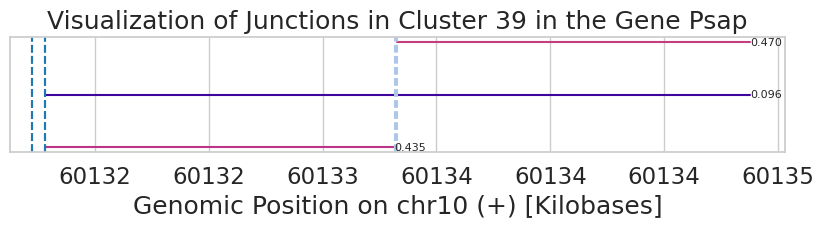

In [21]:
j = "10_60131782_60133316"
visualize_local_events(dat_vis, j, p_usage_ratio=True)

In [23]:
all_juncs_df

,junction_id,counts_total,chrom,chromStart,chromEnd,name,score,strand,thickStart,thickEnd,...,block_add_start,block_subtract_end,intron_length,total_5ss_counts,total_3ss_counts,5SS_usage,3SS_usage,Cluster,gene_id,Count
0,10_5375760_5376254,3,10,5375760,5376254,JUNC00005558,1,-,5375734,5376275,...,26,21,494,10,3,0.3,1.0000,41,ENSMUSG00000096054.4,2
1,10_5375760_5376254,3,10,5375760,5376254,JUNC00013435,2,-,5375698,5376277,...,62,23,494,10,3,0.3,1.0000,41,ENSMUSG00000096054.4,2
2,10_5375760_5386738,7,10,5375760,5386738,JUNC00005560,1,-,5375736,5386797,...,24,59,10978,10,7,0.7,1.0000,41,ENSMUSG00000096054.4,2
3,10_5375760_5386738,7,10,5375760,5386738,JUNC00008647,1,-,5375718,5386797,...,42,59,10978,10,7,0.7,1.0000,41,ENSMUSG00000096054.4,2
4,10_5375760_5386738,7,10,5375760,5386738,JUNC00013434,3,-,5375667,5386794,...,93,56,10978,10,7,0.7,1.0000,41,ENSMUSG00000096054.4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
585,X_165168477_165169947,11,X,165168477,165169947,JUNC00009902,1,+,165168428,165169981,...,49,34,1470,11,16,1.0,0.6875,66,ENSMUSG00000031342.18,3
586,X_165168477_165169947,11,X,165168477,165169947,JUNC00014433,1,+,165168412,165169983,...,65,36,1470,11,16,1.0,0.6875,66,ENSMUSG00000031342.18,3
587,X_165168477_165169947,11,X,165168477,165169947,JUNC00015740,3,+,165168421,165170011,...,56,64,1470,11,16,1.0,0.6875,66,ENSMUSG00000031342.18,3
588,X_165168477_165169947,11,X,165168477,165169947,JUNC00009187,3,+,165168398,165170013,...,79,66,1470,11,16,1.0,0.6875,66,ENSMUSG00000031342.18,3


In [22]:
# get average number of junctions per cluster here 
avg_juncs_per_cluster = all_juncs_df.groupby("Cluster").size().mean()
print("The average number of junctions per cluster is: " + str(avg_juncs_per_cluster))

The average number of junctions per cluster is: 8.93939393939394
